# Detecção de Fake News com Bag-of-words

Processo de detecção de fake news buscando explorar o método Bag-of-Words para realizar o processo de representação de texto e analisar os resultados obtidos ao aplicar posteriormente os algoritmos de classificação: One-Class SVM, K-means e Naive Bayes.

Base de notícias utilizada esta disponível em: https://repositorio.unesp.br/items/dbd004a4-bdb8-4cc7-86b8-cec7e7159979



---



In [ ]:
# Instalação das bibliotecas
!pip install unidecode
!pip install openpyxl
!pip install nltk
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unidecode
import nltk

In [ ]:
# Incorporação das stopwords
nltk.download('stopwords')

from nltk.corpus import stopwords
stopwords_br = stopwords.words('portuguese')

print(stopwords_br)

['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Carregando dados

In [ ]:
# Lendo base de notícias com pandas

dataframe = pd.read_excel("/content/FakeRecogna_no_removal_words.xlsx")
dataframe.head()

,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe
0,\n\nArthur Lira fraudou a votação sobre voto i...,Boato – Está comprovado que a votação sobre o ...,bomba lira fraudar o votação brasília explodir...,política,17/08/2021,\nEdgard Matsuki,https://www.boatos.org/politica/arthur-lira-fr...,0
1,WhatsApp agora permite silenciar conversas e g...,"Opção vinha sendo testada no aplicativo, e foi...",o whatsapp liberar quinta-feira atualização ap...,política,23/10/2020 10h02,Por G1,https://g1.globo.com/economia/tecnologia/notic...,1
2,"Com Lula, Bolsonaro e Ciro, Fortaleza vira mic...",NaN,debater propor o cidade o campanha prefeitura ...,política,27/10/2020 04h00,Carlos Madeiro,https://noticias.uol.com.br/eleicoes/2020/10/2...,1
3,Alesp aprova projeto que multa em até R$ 100 m...,NaN,o alesp assembleia legislativo paulo aprovar h...,saúde,10/02/2021 23h56,10/02/2021 23h56,https://noticias.uol.com.br/saude/ultimas-noti...,1
4,\n Não é verdade que Fauci sabia há 15 anos q...,Publicações compartilhadas dezenas de vezes de...,“ fauci aprovar o hidroxicloroquina haver ano ...,saúde,11/08/2020 às 20:45,AFP Austrália,https://checamos.afp.com//nao-e-verdade-que-fa...,0


In [ ]:
# Exemplo de notícia
dataframe.Noticia[0]

'bomba lira fraudar o votação brasília explodir votar impresso auditável perder roubar umar haver fraudar o votação o câmara deputar imaginar o eleição presidencial bomba bomba bomba bomba lira fraudar o votação brasília explodir'

In [ ]:
dataframe['Categoria'].value_counts()

,count
Categoria,
saúde,4456
política,3951
entretenimento,1409
brasil,904
ciência,602
mundo,580


In [ ]:
from unidecode import unidecode

# Função para limpar texto: remover stopwords, acentos e pontuações
def limpar_texto(texto):
    # Remover stopwords
    texto = " ".join(word for word in texto.split() if word not in stopwords_br)
    # Remover acentos
    texto = unidecode(texto)
    # Remover pontuações e caracteres especiais
    texto = re.sub(r"[^\w\s]", "", texto)
    return texto

# Aplicar a função de limpeza na coluna 'Noticia'
dataframe['Noticia'] = dataframe['Noticia'].apply(limpar_texto)

# Nuvem de palavras de Fake News

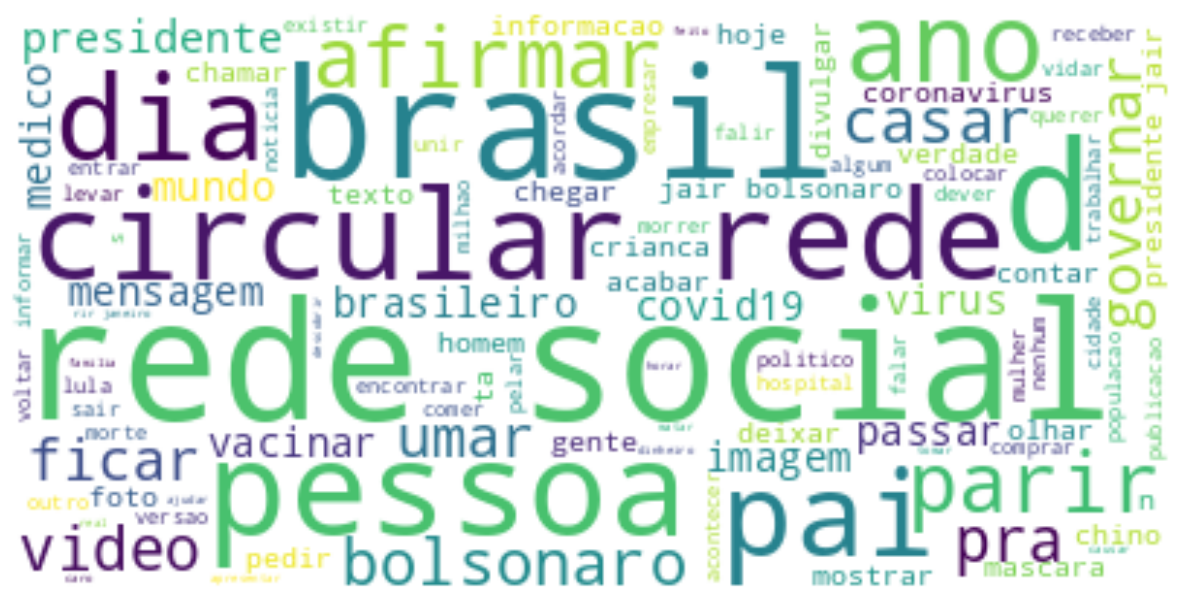

In [ ]:
from wordcloud import WordCloud

# Notícias que são falsas
dataframe_fake = dataframe[dataframe["Classe"] == 0]
texto_fake = ' '.join(i for i in dataframe_fake["Noticia"])

# Plotar nuvem de palavras
wordcloud = WordCloud(background_color="white").generate(texto_fake)
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Nuvem de palavras de notícias verdadeiras

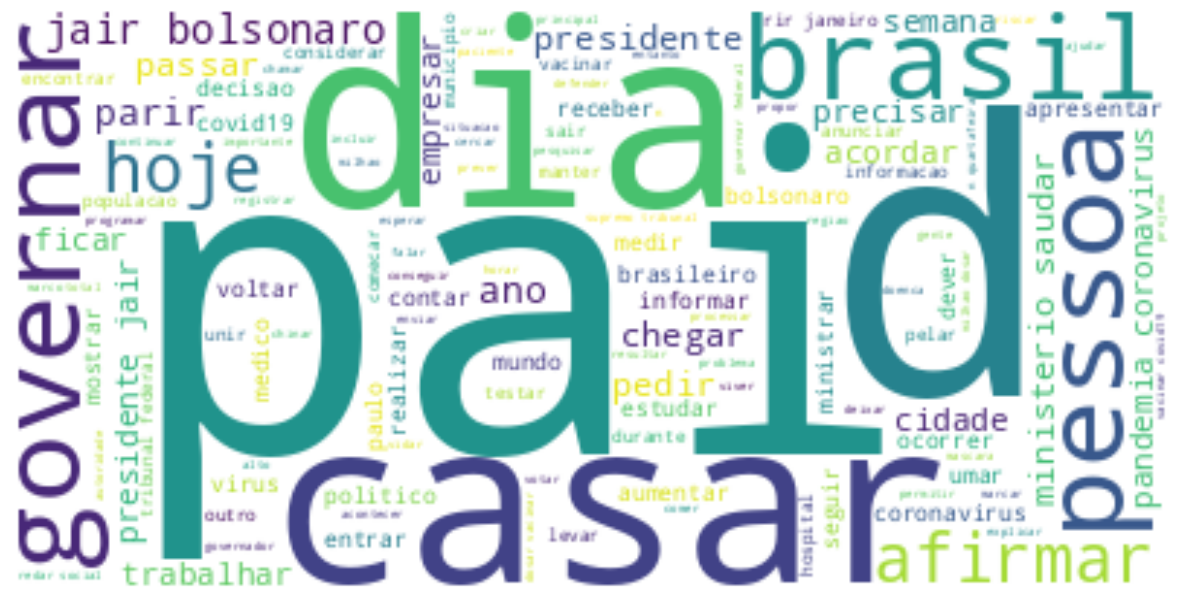

In [ ]:
# Notícias reais
dataframe_real = dataframe[dataframe["Classe"] == 1]
texto_real = ''.join(word for word in dataframe_real['Noticia'])

# Plotar nuvem de palavras
wordcloud = WordCloud(background_color="white").generate(texto_real)
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Classificação

In [ ]:
# Apenas notícias e rótulos
df_news_labels = dataframe[["Noticia", "Classe"]]

# Remover linhas nulas
df_news_labels = df_news_labels.dropna()

df_news_labels.head()

,Noticia,Classe
0,bomba lira fraudar votacao brasilia explodir v...,0
1,whatsapp liberar quintafeira atualizacao aplic...,1
2,debater propor cidade campanha prefeitura fort...,1
3,alesp assembleia legislativo paulo aprovar hoj...,1
4,fauci aprovar hidroxicloroquina ano curar coro...,0


In [ ]:
news = df_news_labels.Noticia
labels = df_news_labels.Classe #0 = fake news; 1 = real news

Classe
0    5951
1    5951
Name: count, dtype: int64


<Axes: >

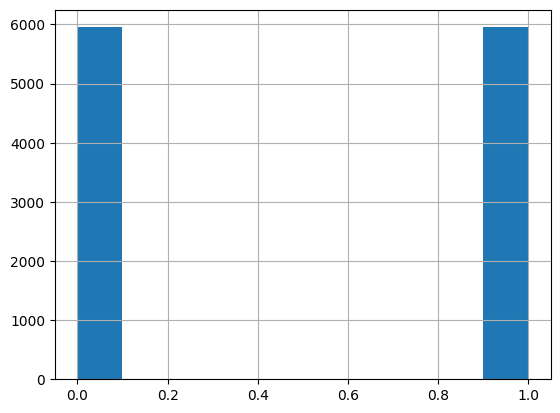

In [ ]:
# Comparação de quantidade entre: Fake news x Notícias reais
print(labels.value_counts())
labels.hist()

In [ ]:
# Importação para executar Bag of Words
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Análise com One-class SVM

In [ ]:
from sklearn.svm import OneClassSVM
from tqdm import tqdm
from sklearn.metrics import accuracy_score


train_accuracies = []
test_accuracies = []

# Separação dos dados de treino e teste
X_train_real, X_test, y_train_real, y_test = train_test_split(news[labels == 1], labels[labels == 1], test_size=0.15, random_state=42)

for i in tqdm(range(100)):
    # Vetorização Bag-of-Words
    bow_model = CountVectorizer(stop_words=stopwords_br)
    X_train = bow_model.fit_transform(X_train_real)
    X_test_bow = bow_model.transform(X_test)

    # Modelo One-Class SVM
    svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.1)
    svm_model.fit(X_train)  # Treina o modelo apenas com dados reais

    # Predições: -1 para anomalias, 1 para "normais"
    y_train_pred = svm_model.predict(X_train)
    y_test_pred = svm_model.predict(X_test_bow)

    # Ajuste de rótulos: anomalias como "0" (falso), normais como "1" (real)
    y_train_pred = [1 if x == 1 else 0 for x in y_train_pred]
    y_test_pred = [1 if x == 1 else 0 for x in y_test_pred]

    # Calcula acurácia de treino e teste
    train_accuracy = accuracy_score(y_train_real, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Calcula acurácia média de treino e teste
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

print("Média de acurácia de treino em 100 épocas:", mean_train_accuracy)
print("Média de acurácia de teste em 100 épocas:", mean_test_accuracy)


100%|██████████| 100/100 [13:50<00:00,  8.31s/it]

Média de acurácia de treino em 100 épocas: 0.8997627520759192
Média de acurácia de teste em 100 épocas: 0.9160134378499439


# Análise com K-means

In [ ]:
from sklearn.cluster import KMeans

train_accuracies = []
test_accuracies = []

# Separação dos dados de treino e teste
X_train_real, X_test, y_train_real, y_test = train_test_split(news[labels == 1], labels[labels == 1], test_size=0.15, random_state=42)

for i in tqdm(range(100)):
    # Vetorização Bag-of-Words
    bow_model = CountVectorizer(stop_words=stopwords_br)
    X_train = bow_model.fit_transform(X_train_real)
    X_test_bow = bow_model.transform(X_test)

    # Modelo K-Means
    kmeans_model = KMeans(n_clusters=2, random_state=42)
    kmeans_model.fit(X_train)

    # Predições
    y_train_pred = kmeans_model.predict(X_train)
    y_test_pred = kmeans_model.predict(X_test_bow)

    # Ajuste de rótulos: Mapeia os rótulos para 0 e 1 com base na maioria
    y_train_pred_mapped = [1 if label == 0 else 0 for label in y_train_pred]
    y_test_pred_mapped = [1 if label == 0 else 0 for label in y_test_pred]

    # Calcula acurácia de treino e teste
    train_accuracy = accuracy_score(y_train_real, y_train_pred_mapped)
    test_accuracy = accuracy_score(y_test, y_test_pred_mapped)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Calcula acurácia média de treino e teste
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)

print("Média de acurácia de treino em 100 épocas:", mean_train_accuracy)
print("Média de acurácia de teste em 100 épocas:", mean_test_accuracy)

100%|██████████| 100/100 [01:13<00:00,  1.35it/s]

Média de acurácia de treino em 100 épocas: 0.7311190193752469
Média de acurácia de teste em 100 épocas: 0.7424412094064949


# Análise com Naive-Bayes

In [ ]:
# Imcorpora algoritmo de Naive Bayes para classificação
from sklearn.naive_bayes import MultinomialNB

sum_train = 0
sum_test = 0

# Loop para avaliar o modelo em 100 divisões de treino/teste
for i in tqdm(range(100)):
    # Dividir os dados em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(news, labels, test_size=0.1)

    # Criar e aplicar o modelo Bag of Words
    bow_model = CountVectorizer(stop_words=stopwords_br)
    X_train = bow_model.fit_transform(X_train)
    X_test = bow_model.transform(X_test)

    # Criar e treinar o modelo Naive Bayes
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # Acumular as acurácias
    sum_train += model.score(X_train, y_train)
    sum_test += model.score(X_test, y_test)

# Calcular e imprimir as médias das acurácias
print("Média de acurácia de treino em 100 épocas:", sum_train / 100)
print("Média de acurácia de teste em 100 épocas:", sum_test / 100)

100%|██████████| 100/100 [01:39<00:00,  1.01it/s]

Média de acurácia de treino em 100 épocas: 0.9512949304453368
Média de acurácia de teste em 100 épocas: 0.9204198152812769


# Referências:

https://www.youtube.com/watch?v=W7aORTUCAqQ&t=1661s